<a href="https://colab.research.google.com/github/Karthikeya81/OPENCV_LAB_RECORD/blob/main/EXPERIMENT_10_Histogram_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EXPERIMENT 10 : Histogram Processing

Upload an image (A 'low contrast' or slightly dark/foggy image works best!):


Saving image2.jpg to image2.jpg

--- Histogram Graphs ---


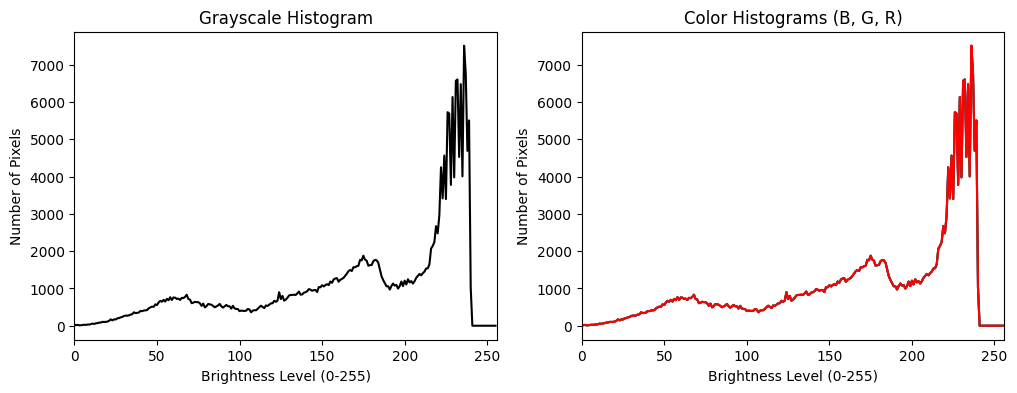


--- Original Grayscale Image ---


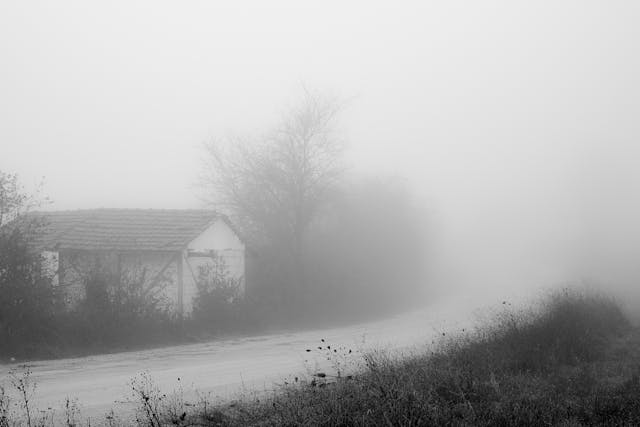


--- Equalized Image (Enhanced Contrast) ---


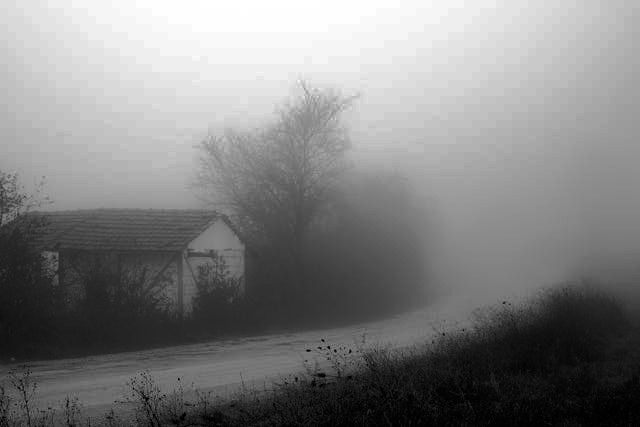

In [1]:
# Import necessary libraries
import cv2
import numpy as np
# Import matplotlib to draw our histogram graphs
from matplotlib import pyplot as plt
from google.colab import files
from google.colab.patches import cv2_imshow

print("Upload an image (A 'low contrast' or slightly dark/foggy image works best!):")
# Read the input image
uploaded = files.upload()
filename = next(iter(uploaded))
image = cv2.imread(filename)

# Convert to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# --- 1. Apply Histogram Calculation (Single Channel Grayscale) ---
# cv2.calcHist([image], [channel], mask, [bins], range)
# [0] is the channel for grayscale. [256] means we want to count all 256 shades.
gray_hist = cv2.calcHist([gray_image], [0], None, [256], [0, 256])

# Set up a plot for the Grayscale Histogram
plt.figure(figsize=(12, 4)) # Make the graph wide
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st graph
plt.title("Grayscale Histogram")
plt.xlabel("Brightness Level (0-255)")
plt.ylabel("Number of Pixels")
plt.plot(gray_hist, color='black')
plt.xlim([0, 256])


# --- 2. Apply Histogram Calculation (Separate B, G, R channels) ---
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd graph
plt.title("Color Histograms (B, G, R)")
plt.xlabel("Brightness Level (0-255)")
plt.ylabel("Number of Pixels")

# OpenCV uses BGR, so we create a list of those colors
colors = ('b', 'g', 'r')
# Loop through the colors and plot them one by one
for i, col in enumerate(colors):
    hist = cv2.calcHist([image], [i], None, [256], [0, 256])
    plt.plot(hist, color=col)
    plt.xlim([0, 256])

# Show the plotted graphs!
print("\n--- Histogram Graphs ---")
plt.show()


# --- 3. Apply Histogram Equalization ---
# Equalization automatically stretches the histogram to cover the full range (0 to 255).
# This dramatically improves contrast!
equalized_image = cv2.equalizeHist(gray_image)


# --- 4. Display all results for visual comparison ---
print("\n--- Original Grayscale Image ---")
cv2_imshow(gray_image)

print("\n--- Equalized Image (Enhanced Contrast) ---")
cv2_imshow(equalized_image)